# 定增项目敏感性分析（通用版本）

## 📌 股票配置区
**修改下方参数来分析不同的定增项目**

| 参数 | 说明 | 光弘科技 | 示例 |
|------|------|----------|------|
| `STOCK_CODE` | 股票代码 | 300735.SZ | 000001.SZ, 600519.SH |
| `STOCK_NAME` | 公司名称 | 光弘科技 | 任意名称 |
| `ISSUE_PRICE` | 发行价格 | 25.0 | 根据定增方案填写 |
| `CURRENT_PRICE` | 当前价格 | 31.25 | 市场最新价 |
| `LOCKUP_PERIOD` | 锁定期（月）| 12 | 通常6/12/18/36 |

---

## 分析目标
本 Notebook 用于分析定增项目对关键参数的敏感性，包括：
- 发行折价率
- 锁定期长度
- 解禁时股价表现
- 破发概率分析

In [7]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

# 获取字体属性（用于绘图时设置字体）
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 库导入成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 库导入成功


## 1. 项目参数设置

In [ ]:
# ============================================================
# 📌 股票配置区 - 修改这里来分析不同的定增项目
# ============================================================

# 方式1: 手动配置（推荐用于快速分析）
STOCK_CONFIG = {
    'code': '300735.SZ',          # 股票代码
    'name': '光弘科技',            # 公司名称
    'issue_price': 20.76,         # 发行价格（元/股）- 从Tushare获取
    'current_price': 25.95,        # 当前价格（元/股）- 从Tushare获取
    'lockup_period': 12,           # 锁定期（月）
    'issue_shares': 5000000,       # 发行数量（股）
    'risk_free_rate': 0.03,        # 无风险利率
    'volatility': 0.3117,          # 年化波动率 - 从Tushare获取
}

# 方式2: 从JSON文件加载（由fetch_gh_data.py生成）
# 取消注释以下代码来加载保存的参数
"""
import json
import os

params_file = '300735_SZ_placement_params.json'
if os.path.exists(params_file):
    with open(params_file, 'r') as f:
        params = json.load(f)
    
    # 更新配置
    STOCK_CONFIG.update({
        'issue_price': params['issue_price'],
        'current_price': params['current_price'],
        'volatility': params['volatility'],
    })
    
    print(f"✅ 已从 {params_file} 加载光弘科技真实数据")
else:
    print(f"⚠️ 未找到 {params_file}，使用手动配置的参数")
    print("   提示: 运行 'python fetch_gh_data.py' 获取最新数据")
"""

# 显示当前配置
print("="*70)
print(f"当前分析标的: {STOCK_CONFIG['name']} ({STOCK_CONFIG['code']})")
print("="*70)
print(f"发行价格: {STOCK_CONFIG['issue_price']} 元/股")
print(f"当前价格: {STOCK_CONFIG['current_price']} 元/股")
print(f"锁定期: {STOCK_CONFIG['lockup_period']} 个月")
print(f"发行折价: {(STOCK_CONFIG['current_price']/STOCK_CONFIG['issue_price'] - 1)*100:+.2f}%")
print("="*70)

# ============================================================
# 以下代码自动生成项目参数，无需修改
# ============================================================

In [8]:
# 使用配置创建分析器（自动从 STOCK_CONFIG 生成）
PROJECT_PARAMS = {
    'issue_price': STOCK_CONFIG['issue_price'],
    'issue_shares': STOCK_CONFIG['issue_shares'],
    'lockup_period': STOCK_CONFIG['lockup_period'],
    'current_price': STOCK_CONFIG['current_price'],
    'risk_free_rate': STOCK_CONFIG['risk_free_rate']
}

# 创建分析器实例
analyzer = PrivatePlacementRiskAnalyzer(**PROJECT_PARAMS)

# 显示项目摘要
summary = analyzer.generate_summary_report()
print('=== 项目摘要 ===')
print(f"分析标的: {STOCK_CONFIG['name']}")
print(f"股票代码: {STOCK_CONFIG['code']}")
print(f"发行价格: {summary['project_info']['issue_price']} 元/股")
print(f"当前价格: {summary['project_info']['current_price']} 元/股")
print(f"折价率: {summary['key_metrics']['discount_to_current']}")
print(f"融资金额: {summary['project_info']['issue_amount']/10000:.2f} 万元")
print(f"锁定期: {summary['project_info']['lockup_period_months']} 个月")

NameError: name 'STOCK_CONFIG' is not defined

## 2. 盈亏平衡价格敏感性

# 不同期望收益率下的盈亏平衡价格
target_returns = np.linspace(0.05, 0.50, 10)  # 5%到50%的年化收益率
break_even_prices = [analyzer.calculate_break_even_price(r) for r in target_returns]

# 绘制敏感性曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(target_returns * 100, break_even_prices, 'b-', linewidth=2, label='盈亏平衡价格')
ax.axhline(y=PROJECT_PARAMS['issue_price'], color='r', linestyle='--', label='发行价格')
ax.axhline(y=PROJECT_PARAMS['current_price'], color='g', linestyle='--', label='当前价格')

ax.set_xlabel('期望年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title(f'{STOCK_CONFIG["name"]} - 不同收益率要求下的盈亏平衡价格', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据点
print('\n=== 盈亏平衡价格分析 ===')
for ret in [0.10, 0.15, 0.20, 0.25, 0.30]:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (analyzer.current_price - be_price) / analyzer.current_price
    status = "✅ 安全" if distance > 0 else "⚠️ 风险"
    print(f"{ret*100:.0f}%年化收益率: 盈亏平衡={be_price:.2f}元, 距离当前价={distance*100:+.2f}% {status}")

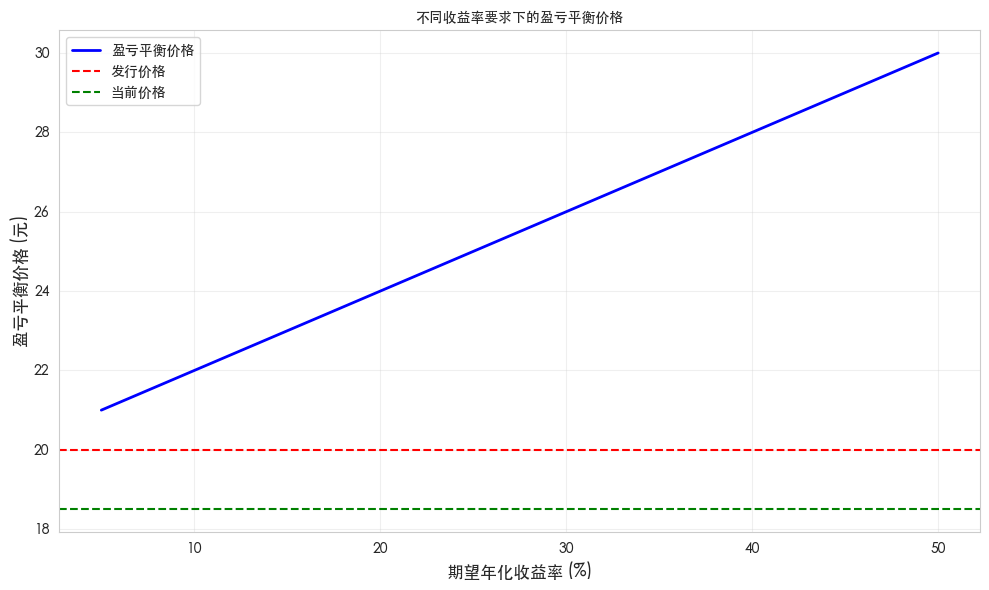


=== 盈亏平衡价格分析 ===
10%年化收益率: 盈亏平衡=22.00元, 距离当前价=-18.92%
15%年化收益率: 盈亏平衡=23.00元, 距离当前价=-24.32%
20%年化收益率: 盈亏平衡=24.00元, 距离当前价=-29.73%
25%年化收益率: 盈亏平衡=25.00元, 距离当前价=-35.14%
30%年化收益率: 盈亏平衡=26.00元, 距离当前价=-40.54%


In [3]:
# 不同期望收益率下的盈亏平衡价格
target_returns = np.linspace(0.05, 0.50, 10)  # 5%到50%的年化收益率
break_even_prices = [analyzer.calculate_break_even_price(r) for r in target_returns]

# 绘制敏感性曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(target_returns * 100, break_even_prices, 'b-', linewidth=2, label='盈亏平衡价格')
ax.axhline(y=PROJECT_PARAMS['issue_price'], color='r', linestyle='--', label='发行价格')
ax.axhline(y=PROJECT_PARAMS['current_price'], color='g', linestyle='--', label='当前价格')

ax.set_xlabel('期望年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title('不同收益率要求下的盈亏平衡价格', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据点
print('\n=== 盈亏平衡价格分析 ===')
for ret in [0.10, 0.15, 0.20, 0.25, 0.30]:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (analyzer.current_price - be_price) / analyzer.current_price
    print(f"{ret*100:.0f}%年化收益率: 盈亏平衡={be_price:.2f}元, 距离当前价={distance*100:.2f}%")

## 3. 锁定期敏感性分析

NameError: name 'df_lockup' is not defined

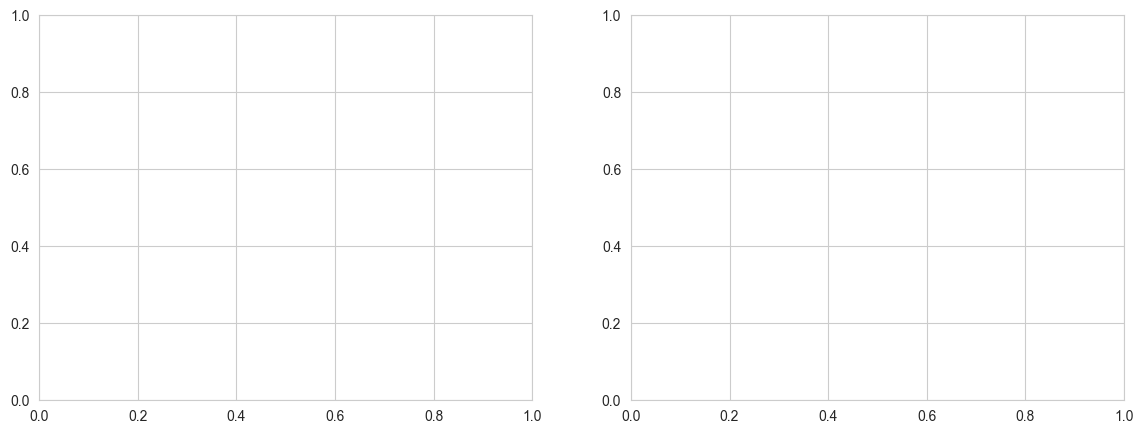

In [4]:
# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(df_lockup['lockup_period'], df_lockup['break_even_price'], color='steelblue', alpha=0.7)
ax1.axhline(y=PROJECT_PARAMS['current_price'], color='r', linestyle='--', label='当前价格')
ax1.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax1.set_ylabel('盈亏平衡价格 (元)', fontproperties=font_prop)
ax1.set_title('锁定期对盈亏平衡价格的影响', fontproperties=font_prop)
ax1.legend(prop=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

ax2.plot(df_lockup['lockup_period'], df_lockup['required_increase']*100, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax2.set_ylabel('需要涨幅 (%)', fontproperties=font_prop)
ax2.set_title('锁定期与需要涨幅的关系', fontproperties=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 不同锁定期下的盈亏平衡分析
lockup_periods = [6, 9, 12, 18, 24, 36]  # 不同的锁定期（月）
target_return = 0.20  # 20%年化收益率

lockup_analysis = []
for period in lockup_periods:
    # 修改分析器的锁定期
    analyzer.lockup_period = period
    
    # 计算盈亏平衡价格（20%年化收益率）
    be_price = analyzer.calculate_break_even_price(target_return)
    
    # 计算需要的涨幅
    required_increase = (be_price - analyzer.issue_price) / analyzer.issue_price
    
    lockup_analysis.append({
        'lockup_period': period,
        'break_even_price': be_price,
        'required_increase': required_increase
    })

df_lockup = pd.DataFrame(lockup_analysis)

print('=== 锁定期敏感性分析 ===')
print(f"{'锁定期(月)':<12} {'盈亏平衡价':<15} {'需要涨幅':<12}")
print('-'*40)
for _, row in df_lockup.iterrows():
    print(f"{int(row['lockup_period']):<8} {row['break_even_price']:>10.2f}元     {row['required_increase']*100:>8.2f}%")

## 4. 破发概率分析

In [ ]:
# 不同波动率下的盈亏概率分析
volatilities = np.linspace(0.15, 0.60, 10)  # 15%到60%的年化波动率
drift = 0.08  # 假设年化收益率8%

prob_analysis = []
for vol in volatilities:
    # 简化的盈亏概率计算（基于正态分布假设）
    # 使用锁定期收益率的标准差
    lockup_vol = vol * np.sqrt(PROJECT_PARAMS['lockup_period'] / 12)
    lockup_drift = drift * (PROJECT_PARAMS['lockup_period'] / 12)
    
    # 计算盈亏平衡需要的收益率
    required_return = (analyzer.current_price - analyzer.issue_price) / analyzer.issue_price
    
    # 计算盈利概率（使用正态分布的 CDF）
    from scipy.stats import norm
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = 1 - norm.cdf(-z_score)  # 盈利概率
    loss_prob = 1 - profit_prob  # 破发概率
    
    prob_analysis.append({
        'volatility': vol,
        'profit_probability': profit_prob,
        'loss_probability': loss_prob
    })

df_prob = pd.DataFrame(prob_analysis)

print('\n=== 波动率敏感性分析 ===')
print(f"{'波动率':<10} {'盈利概率':<12} {'破发概率':<12}")
print('-'*36)
for _, row in df_prob.iterrows():
    if row['volatility'] * 100 % 5 == 0:  # 只打印5%倍数的波动率
        print(f"{int(row['volatility']*100):>3}%      {row['profit_probability']*100:>7.1f}%      {row['loss_probability']*100:>7.1f}%")

In [ ]:
# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_prob['volatility']*100, df_prob['profit_probability']*100, 
        'g-o', linewidth=2, markersize=10, label='盈利概率')
ax.plot(df_prob['volatility']*100, df_prob['loss_probability']*100, 
        'r-s', linewidth=2, markersize=10, label='破发概率')
ax.set_xlabel('年化波动率 (%)', fontproperties=font_prop)
ax.set_ylabel('概率 (%)', fontproperties=font_prop)
ax.set_title('不同波动率下的盈亏概率分析', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 参数敏感性分析（龙卷风图）
# 分析各参数对收益率的影响

# 基准参数
base_params = {
    'issue_price': 20.0,
    'current_price': 18.5,
    'lockup_period': 12,
    'volatility': 0.35,
    'drift': 0.08
}

# 计算基准收益率
def calculate_return_params(params):
    period_years = params['lockup_period'] / 12
    vol_period = params['volatility'] * np.sqrt(period_years)
    drift_period = params['drift'] * period_years
    required_return = (params['current_price'] - params['issue_price']) / params['issue_price']
    z_score = (drift_period - required_return) / vol_period
    from scipy.stats import norm
    profit_prob = 1 - norm.cdf(-z_score)
    return profit_prob

base_return = calculate_return_params(base_params)

# 参数变化分析
param_changes = []
changes = [-0.2, -0.1, 0.1, 0.2]  # ±10%, ±20%

# 1. 发行价格敏感性
for change in changes:
    params = base_params.copy()
    params['issue_price'] = base_params['issue_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'发行价 ({int(change*100)}%)', 'impact_percent': impact})

# 2. 当前价格敏感性
for change in changes:
    params = base_params.copy()
    params['current_price'] = base_params['current_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'当前价 ({int(change*100)}%)', 'impact_percent': impact})

# 3. 锁定期敏感性
for change in changes:
    params = base_params.copy()
    params['lockup_period'] = base_params['lockup_period'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'锁定期 ({int(change*100)}%)', 'impact_percent': impact})

# 4. 波动率敏感性
for change in changes:
    params = base_params.copy()
    params['volatility'] = base_params['volatility'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'波动率 ({int(change*100)}%)', 'impact_percent': impact})

# 按影响程度排序
df_tornado = pd.DataFrame(param_changes).sort_values('impact_percent')

print('\n=== 参数敏感性排序（龙卷风图）===')
print(f"{'参数':<25} {'对盈利概率的影响':<15}")
print('-'*40)
for _, row in df_tornado.iterrows():
    print(f"{row['parameter']:<20} {row['impact_percent']:>8.2f}%")

## 5. 龙卷风图 - 参数敏感性排序

In [ ]:
# 绘制龙卷风图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_tornado['parameter'], df_tornado['impact_percent'], color='coral')
ax.set_xlabel('对收益率的影响 (%)', fontproperties=font_prop)
ax.set_title('参数敏感性排序（龙卷风图）', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, axis='x', alpha=0.3)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

## 6. 敏感性分析结论

In [ ]:
print('\n' + '='*50)
print('敏感性分析结论')
print('='*50)
print(f"\n1. 当前价格较发行价: {(analyzer.current_price/analyzer.issue_price - 1)*100:.2f}%")
print(f"\n2. 20%年化收益率要求下的盈亏平衡价: {analyzer.calculate_break_even_price(0.20):.2f}元")
print(f"\n3. 当前价距离盈亏平衡价: {(analyzer.current_price - analyzer.calculate_break_even_price(0.20))/analyzer.current_price*100:.2f}%")
print(f"\n4. 在30%年化波动率假设下，盈利概率约: {df_prob[df_prob['volatility']==0.3]['profit_probability'].values[0]*100:.1f}%")
print(f"\n5. 最敏感的参数是: {df_tornado.iloc[-1]['parameter']}")